In [ ]:
try:
    import geopandas as gpd
except ImportError:
    !pip install geopandas
    import geopandas as gpd
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, interact_manual
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, interact_manual
try:
    import statsmodels.api as sm
except ImportError:
    !pip install statsmodels
    import statsmodels.api as sm
try:
    import pycountry
except ImportError:
    !pip install pycountry
    import pycountry
try:
    import country_converter as coco
except ImportError:
    !pip install country_converter
    import country_converter as coco
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from statsmodels.miscmodels.ordinal_model import OrderedModel

### Package Setup and Imports

This cell loads the Python packages needed for the project. Some packages are installed only if they are not already available in the environment, which helps the notebook run from start to finish without manual setup. The imported libraries support data cleaning, country-code matching, regression modeling, random forest modeling, and visualization.

In [ ]:
def add_iso3_column(df, name_column):
    cc = coco.CountryConverter()
    df['iso3'] = cc.convert(names=df[name_column], to='ISO3')
    # Filter out non-country entries (like 'World' or 'Arab World')
    df = df[df['iso3'] != 'not_found']
    return df

### Add ISO3 Country Codes

This function converts country names into standardized ISO3 codes using the country_converter package. Since the datasets come from different sources, country names are not always consistent, which makes merging difficult. Creating a common ISO3 identifier allows us to align all datasets accurately. Non-country entries are removed to keep the data focused on valid country observations.

In [ ]:
def reshape_to_long(df, value_name):
    # Assumes 'iso3' and 'country_name' are columns
    # and all other columns are year values
    id_vars = ['iso3', 'country_name']
    df_long = df.melt(id_vars=id_vars, var_name='year', value_name=value_name)
    df_long['year'] = df_long['year'].astype(int)
    return df_long

### Reshape Data to Long Format

This function converts each dataset from wide format to long format. In some of the datasets, particularly those from the World Bank and IMF, each year is stored as a separate column, which makes them difficult to merge. By reshaping into a long format with one row per country and year, we can align all variables on a common structure and prepare the data for merging and then analysis.

In [ ]:
def merge_macro_datasets(base_df, feature_list):
    master_df = base_df.copy()
    for feature_df in feature_list:
        master_df = master_df.merge(feature_df, on=['iso3', 'year'], how='left')
    return master_df

### Merge Macroeconomic Datasets

This function combines everything but our Sovereign Credit Ratings dataset into a single table using ISO3 country codes and year. Each dataset is merged one at a time using a left join so that we keep all observations from the base dataset while adding new variables when available. This creates a unified dataset where all macro indicators are aligned by country and year, which is necessary for running the models later.

In [ ]:
# =====================================================================
# MASTER DATA STANDARDIZATION PIPELINE
# =====================================================================

# === SILENCE THE WARNINGS ===
import logging
logging.getLogger('country_converter').setLevel(logging.ERROR)

# Reload all data to ensure a clean slate ===
# IMF Data
gov_debt = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/General%20Govt%20Debt.csv.csv')
fiscal_balance = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/Fiscal%20Balance.csv')
current_account = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/Current%20Account.csv')

# World Bank Data
external_debt = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/External%20Debt.csv', skiprows=4)
gdp_per_capita = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/GDP%20Per%20Capita.csv', skiprows=4)
inflation = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/Inflation.csv', skiprows=4)
gdp_growth = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/GDP%20Growth.csv', skiprows=4)

# Bank of Canada Data
boc = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/BoC-BoE-Database-2025(Debt_2025).csv', skiprows = 64, encoding = 'latin1')

# Target Variable Data
CSDR = pd.read_csv('https://github.com/D0CT17/econ-148-final-project/raw/refs/heads/main/Cleaned%20Current%20Sovereign%20Debt%20Ratings.csv')


# === STEP 2: Standardize 'Country Name' columns ===
gov_debt = gov_debt.rename(columns={gov_debt.columns[0]: 'country_name'})
fiscal_balance = fiscal_balance.rename(columns={fiscal_balance.columns[0]: 'country_name'})
current_account = current_account.rename(columns={current_account.columns[0]: 'country_name'})
external_debt = external_debt.rename(columns={'Country Name': 'country_name'})
gdp_per_capita = gdp_per_capita.rename(columns={'Country Name': 'country_name'})
inflation = inflation.rename(columns={'Country Name': 'country_name'})
gdp_growth = gdp_growth.rename(columns={'Country Name': 'country_name'})
boc = boc.rename(columns={'DEBT_COUNTRY': 'country_name', 'DEBT_YEAR': 'year'})
CSDR = CSDR.rename(columns={'Country Name': 'country_name'})


# === STEP 3: Apply your teammate's ISO function to ALL datasets ===
gov_debt = add_iso3_column(gov_debt, 'country_name')
fiscal_balance = add_iso3_column(fiscal_balance, 'country_name')
current_account = add_iso3_column(current_account, 'country_name')
gdp_per_capita = add_iso3_column(gdp_per_capita, 'country_name')
inflation = add_iso3_column(inflation, 'country_name')
gdp_growth = add_iso3_column(gdp_growth, 'country_name')
external_debt = add_iso3_column(external_debt, 'country_name')
boc = add_iso3_column(boc, 'country_name')
CSDR = add_iso3_column(CSDR, 'country_name')


# === STEP 4: Move 'iso3' column to Index 1 (Next to Country Name) ===
# Create a quick helper function to do this cleanly
def move_iso_to_front(df):
    if 'iso3' in df.columns:
        iso_col = df.pop('iso3')
        df.insert(1, 'iso3', iso_col)
    return df

# Apply the helper function
gov_debt = move_iso_to_front(gov_debt)
fiscal_balance = move_iso_to_front(fiscal_balance)
current_account = move_iso_to_front(current_account)
gdp_per_capita = move_iso_to_front(gdp_per_capita)
inflation = move_iso_to_front(inflation)
gdp_growth = move_iso_to_front(gdp_growth)
external_debt = move_iso_to_front(external_debt)
boc = move_iso_to_front(boc)
CSDR = move_iso_to_front(CSDR)

### Load and Standardize Source Data

This cell loads all nine of our datasets, three from the IMF, four from the World Bank, one from the Bank of Canada, and lastly one provided by our Professor for Sovereign Credit Ratings by Bloomberg. Since these files come from different sources, the country name columns are first renamed to a common format. ISO3 country codes are then added so the datasets can be merged reliably later. The ISO3 column is also moved to the front to make the tables easier to inspect/analyze.

In [ ]:
# =====================================================================
# MASTER RESHAPE: CONSOLIDATING ALL MACRO DATASETS
# =====================================================================

# 1. Establish dataset groups
# (Partner function requires lowercase)
imf_list = [gov_debt, fiscal_balance, current_account]
wb_list = [gdp_per_capita, inflation, gdp_growth, external_debt]
boc_list = [boc]

# 2. CLEAN IMF DATA (Drop metadata)
for df in imf_list:
    if 'Estimates start after' in df.columns:
        df.drop(columns=['Estimates start after'], inplace=True)

# 3. CLEAN WORLD BANK DATA (Drop text and empty unnamed columns)
wb_text_cols = ['Country Code', 'Indicator Name', 'Indicator Code']
for df in wb_list:
    # Drop indicator columns
    df.drop(columns=wb_text_cols, inplace=True, errors='ignore')
    # Drop any hidden 'Unnamed' columns at the end
    unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
    df.drop(columns=unnamed_cols, inplace=True)

# 4. CLEAN BOC DATA (Drop unnecessary columns)
boc = boc[['iso3', 'country_name', "year", "DEBT_TOTAL_2025"]]

# 5. CLEAN CSDR DATA (Drop unnecessary columns, fix ISO3 names, drop missing ISO3 rows)
CSDR = CSDR.iloc[:, [1, 2, 8, 10, 11, 13]]
CSDR.columns = ['iso3', 'country_name', 'moodys_rating', 'moodys_score', 'sp_rating', 'sp_score']
CSDR.loc[CSDR['country_name'] == 'Abu Dhabi', 'iso3'] = 'ARE'
CSDR.loc[CSDR['country_name'] == 'Dubai', 'iso3'] = 'ARE'
CSDR = CSDR[CSDR['iso3'] != 'not_found']

# 6. EXECUTE RESHAPE_TO_LONG
# IMF Results
gov_debt_long = reshape_to_long(gov_debt, 'gov_debt')
fiscal_balance_long = reshape_to_long(fiscal_balance, 'fiscal_balance')
current_account_long = reshape_to_long(current_account, 'current_account')

# World Bank Results
gdp_per_capita_long = reshape_to_long(gdp_per_capita, 'gdp_per_capita')
inflation_long = reshape_to_long(inflation, 'inflation')
gdp_growth_long = reshape_to_long(gdp_growth, 'gdp_growth')
external_debt_long = reshape_to_long(external_debt, 'external_debt')

print("Success! All 8 macro datasets are now in 'Long' format.")

Success! All 8 macro datasets are now in 'Long' format.


### Clean and Reshape Macroeconomic Data

This cell removes extra metadata from the IMF, World Bank, and Bank of Canada datasets so that only the variables needed for analysis remain. The Sovereign Credit Ratings data is also narrowed to Moody’s and S&P ratings and scores, which are the target outcomes for the models. After cleaning, the macroeconomic datasets are reshaped into long format so each row represents one country in one year. This structure is needed before all variables can be merged into a single modeling dataset.

In [ ]:
# =====================================================================
# MASTER MERGE
# =====================================================================

# 1. Helper to flatten and clean dataframes before merging
def prep_for_merge(df):
    df = df.copy()
    # Flatten columns if they are MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    # Force types to prevent 'unhashable' or mismatch errors
    df['year'] = df['year'].astype(int)
    df['iso3'] = df['iso3'].astype(str)
    df['country_name'] = df['country_name'].astype(str)
    return df

# 2. Prep all datasets
base = prep_for_merge(gov_debt_long)
fisc = prep_for_merge(fiscal_balance_long)
curr = prep_for_merge(current_account_long)
gdp_p = prep_for_merge(gdp_per_capita_long)
inf = prep_for_merge(inflation_long)
gdp_g = prep_for_merge(gdp_growth_long)
ext = prep_for_merge(external_debt_long)
bank = prep_for_merge(boc)

# 3. Explicit Merge
master_df = base.merge(fisc, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(curr, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(gdp_p, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(inf, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(gdp_g, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(ext, on=['iso3', 'year', 'country_name'], how='left')
master_df = master_df.merge(bank, on=['iso3', 'year', 'country_name'], how='left')

# 4. Final Cleanup
master_df = master_df[master_df['iso3'] != 'not_found']
master_df = master_df.sort_values(['iso3', 'year']).reset_index(drop=True)

print(f"Master Dataset created! Final shape: {master_df.shape}")

Master Dataset created! Final shape: (23972, 11)


### Merge Macro Variables into a Master Dataset

This cell prepares each long format dataset for merging by standardizing column types for country codes, country names, and years. The macroeconomic variables are then merged one by one using ISO3 code, year, and country name. The result is a master country-year dataset that combines debt, fiscal balance, current account, GDP per capita, inflation, growth, external debt, and default related data for later modeling.

In [ ]:
# =====================================================================
# THE FINAL PROJECT MERGE: MACRO DATA + TARGET RATINGS
# =====================================================================

# 1. Start with your existing merged macro data (master_df)
# Ensure columns are numeric and not strings like "no data"
cols_to_fix = ['gov_debt', 'fiscal_balance', 'current_account']
for col in cols_to_fix:
    master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

# 2. Merge with your standardized CSDR ratings
# We merge on 'iso3' so the current rating is mapped to all years for that country
final_project_df = master_df.merge(
    CSDR[['iso3', 'moodys_score', 'sp_score', 'moodys_rating', 'sp_rating']],
    on='iso3',
    how='left')

# 3. Define default_history
final_project_df['default_history'] = (
    final_project_df.groupby('iso3')['DEBT_TOTAL_2025']
    .transform(lambda x: (x > 0).shift(1).expanding().max())
    .fillna(0)
    .astype(int))
final_project_df = final_project_df.drop(columns=['DEBT_TOTAL_2025'])

# 4. Final Filter: Drop rows that have NO economic data at all or that the agencies did not track; impute missing data
master_cols = ['gov_debt', 'fiscal_balance', 'current_account', 'gdp_per_capita', 'inflation', 'gdp_growth', 'external_debt']
final_project_df = final_project_df.dropna(
    subset=master_cols,
    how='all')
final_project_df = final_project_df.dropna(subset=['moodys_rating', 'sp_rating'], how='all')
final_project_df[master_cols] = final_project_df.groupby('iso3')[master_cols].transform(lambda x: x.ffill().bfill())
final_project_df[['inflation','gdp_growth']] = final_project_df.groupby('year')[['inflation','gdp_growth']].transform(lambda x: x.fillna(x.median()))

# 5. Sort by country and year
final_project_df = final_project_df.sort_values(['iso3', 'year']).reset_index(drop=True)

# 6. Remove predictions
final_project_df = final_project_df[final_project_df['year']<2025]

print(f"Grand Success! Final Dataset Shape: {final_project_df.shape}")
final_project_df

Grand Success! Final Dataset Shape: (6173, 15)


,iso3,country_name,year,gov_debt,fiscal_balance,current_account,gdp_per_capita,inflation,gdp_growth,external_debt,moodys_score,sp_score,moodys_rating,sp_rating,default_history
0,ABW,Aruba,1985,55.1,-0.8,-25.3,6767.559229,4.032258,16.078431,NaN,10.0,8.0,Baa3,BBB+,0
1,ABW,Aruba,1986,55.1,-0.8,-25.3,6767.559229,1.073966,16.078431,NaN,10.0,8.0,Baa3,BBB+,0
2,ABW,Aruba,1987,55.1,-0.8,-25.3,8244.045660,3.643045,16.078431,NaN,10.0,8.0,Baa3,BBB+,0
3,ABW,Aruba,1988,55.1,-0.8,-25.3,10056.261393,3.121868,18.648649,NaN,10.0,8.0,Baa3,BBB+,0
4,ABW,Aruba,1989,55.1,-0.8,-25.3,11507.217151,3.991628,12.129841,NaN,10.0,8.0,Baa3,BBB+,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105,ZMB,Zambia,2020,140.0,-13.8,11.8,951.644317,15.733060,-2.785055,167.518099,18.0,99.0,Caa2,SD,1
7106,ZMB,Zambia,2021,111.0,-8.1,11.9,1127.160779,22.020768,6.234922,133.551637,18.0,99.0,Caa2,SD,1
7107,ZMB,Zambia,2022,99.5,-7.8,3.7,1447.123101,10.993204,5.211224,103.673946,18.0,99.0,Caa2,SD,1
7108,ZMB,Zambia,2023,129.1,-5.5,-3.0,1330.727806,10.884532,5.367943,110.675742,18.0,99.0,Caa2,SD,1


### Create the Final Modeling Dataset

This cell merges the macroeconomic master dataset with Moody’s and S&P sovereign credit ratings using ISO3 country codes. It also creates the default history variable from the Bank of Canada data, which captures whether a country had a prior default related event.

After merging, the cell removes observations without usable macroeconomic data or ratings. Missing macro values are filled within each country when possible, and remaining inflation and GDP growth gaps are filled using yearly medians. The final dataset is sorted by country and year and limited to observed years before 2025 so it is ready for modeling.

In [ ]:
# Force pandas to show all columns without squeezing them
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Display the summary table transposed
summary_table = final_project_df.describe().T
summary_table['missing_values'] = final_project_df.isnull().sum()
summary_table

,count,mean,std,min,25%,50%,75%,max,missing_values
year,6173.0,2002.641341,12.802009,1980.000000,1992.000000,2003.000000,2014.000000,2024.000000,0
gov_debt,5956.0,54.176142,41.485823,0.000000,28.175000,46.700000,68.825000,345.500000,217
fiscal_balance,6001.0,-2.123296,6.237483,-144.500000,-4.500000,-2.100000,0.200000,52.300000,172
current_account,6001.0,-1.204583,10.099112,-243.000000,-5.100000,-1.900000,2.200000,125.500000,172
gdp_per_capita,5593.0,14525.847454,21729.620129,22.952133,1596.020630,5369.109786,18885.427447,206780.590353,580
inflation,6173.0,33.201854,290.286282,-16.117326,2.127468,4.370736,8.900000,11749.639632,0
gdp_growth,6173.0,3.072035,5.964534,-64.047107,1.342810,3.420013,5.445281,86.826748,0
external_debt,2883.0,57.092694,60.999290,0.745456,27.691251,46.173862,69.900460,1233.099144,3290
moodys_score,6173.0,15.878341,21.729818,1.000000,6.000000,11.000000,16.000000,100.000000,0
sp_score,6173.0,17.355905,23.872484,1.000000,5.000000,11.000000,16.000000,100.000000,0


### Summary Statistics and Missing Data

This cell generates summary statistics for all variables in the final dataset and transposes the table so each variable can be read more easily. It also adds a column that counts missing values for each variable. This helps confirm that the data cleaning steps worked and shows where missing data may still affect the models.

In [ ]:
# Select features and target
features = ['gov_debt', 'fiscal_balance', 'current_account', 'gdp_per_capita', 'inflation', 'gdp_growth', 'default_history']
logit_m = final_project_df[features + ['moodys_rating', 'moodys_score']].dropna().copy()

# Ensure features are numeric (fixes the 'dtype object' error)
logit_m[features] = logit_m[features].apply(pd.to_numeric, errors='coerce')
logit_m['gdp_per_capita'] = logit_m['gdp_per_capita'] / 1000

# Set the rating as an ordered categorical based on the score
logit_m = logit_m.sort_values('moodys_score', ascending=True)
logit_m['moodys_rating'] = pd.Categorical(logit_m['moodys_rating'],
                                          categories=logit_m['moodys_rating'].unique(),
                                          ordered=True)

# Fit Ordered Logit
model_m = OrderedModel(logit_m['moodys_rating'], logit_m[features], distr='logit')
res_m = model_m.fit(method='bfgs', disp=False)
print(res_m.summary())

print("Converged:", res_m.mle_retvals.get('converged'))
print("Iterations:", res_m.mle_retvals.get('iterations'))
print("Log-likelihood:", res_m.llf)

import numpy as np
grad = model_m.score(res_m.params)
print("Max abs gradient:", np.max(np.abs(grad)))
print("Gradient norm:", np.linalg.norm(grad))

                             OrderedModel Results                             
Dep. Variable:          moodys_rating   Log-Likelihood:                -13064.
Model:                   OrderedModel   AIC:                         2.618e+04
Method:            Maximum Likelihood   BIC:                         2.637e+04
Date:                Thu, 07 May 2026                                         
Time:                        09:31:38                                         
No. Observations:                5123                                         
Df Residuals:                    5095                                         
Df Model:                           7                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
gov_debt            0.0074      0.001     11.410      0.000       0.006       0.009
fiscal_balance     -0.0130      0.005

### Moody’s Ordered Logit Model

This cell estimates the baseline econometric model for Moody’s sovereign ratings. The model uses macroeconomic variables such as debt, fiscal balance, current account, GDP per capita, inflation, GDP growth, and default history to predict ordered credit rating categories.

Moody’s ratings are treated as ordered categories based on their numeric scores, which fits the structure of credit ratings better than a standard linear regression. GDP per capita is scaled to thousands of dollars so the coefficient is easier to read. The convergence and gradient checks are included to confirm that the model estimated successfully.

In [ ]:
# Select features and target
logit_s = final_project_df[features + ['sp_rating', 'sp_score']].dropna().copy()
logit_s = logit_s[logit_s['sp_score'] <= 21].copy()

# Ensure features are numeric
logit_s[features] = logit_s[features].apply(pd.to_numeric, errors='coerce')
logit_s['gdp_per_capita'] = logit_s['gdp_per_capita'] / 1000

#Drops Not Rated rows
logit_s = logit_s[~logit_s['sp_rating'].isin(['NR'])].copy()

# Set the rating as an ordered categorical based on the score
logit_s = logit_s.sort_values('sp_score', ascending=True)
logit_s['sp_rating'] = pd.Categorical(logit_s['sp_rating'],
                                        categories=logit_s['sp_rating'].unique(),
                                        ordered=True)

# Fit Ordered Logit
model_s = OrderedModel(logit_s['sp_rating'], logit_s[features], distr='logit')
res_s = model_s.fit(method='bfgs', disp=False, maxiter=20000)
print(res_s.summary())
print("Converged:", res_s.mle_retvals.get('converged'))
print("Iterations:", res_s.mle_retvals.get('iterations'))
print("Log-likelihood:", res_s.llf)

import numpy as np
grad = model_s.score(res_s.params)
print("Max abs gradient:", np.max(np.abs(grad)))

                             OrderedModel Results                             
Dep. Variable:              sp_rating   Log-Likelihood:                -11001.
Model:                   OrderedModel   AIC:                         2.205e+04
Method:            Maximum Likelihood   BIC:                         2.221e+04
Date:                Thu, 07 May 2026                                         
Time:                        09:32:01                                         
No. Observations:                4699                                         
Df Residuals:                    4675                                         
Df Model:                           7                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
gov_debt            0.0052      0.001      7.061      0.000       0.004       0.007
fiscal_balance     -0.0097      0.005

### S&P Ordered Logit Model

This cell estimates the ordered logit model for S&P sovereign ratings using the same set of macroeconomic variables. The ratings are treated as ordered categories based on their score, which matches the structure of credit ratings.

Rows labeled as Not Rated are removed since they do not provide meaningful ranking information. GDP per capita is scaled to make the coefficients easier to interpret. The model is then fitted and checked for convergence to ensure the estimation is stable.

In [ ]:

# =====================================================================
# Random Forest Model Moody's
# =====================================================================

# Prepare and filter out non-standard scores (Withdrawn Rating (WR)= 30, Selective Default (SD) = 99/100) from training data, keeping them would distort model training and inflate errors
rf_m_data = final_project_df[features + ['moodys_score', 'country_name']].dropna().copy()
rf_m_data = rf_m_data[rf_m_data['moodys_score'] <= 22]
rf_m_data[features] = rf_m_data[features].apply(pd.to_numeric, errors='coerce')

# Train model and split 80/20 train/test
from sklearn.model_selection import train_test_split
X_m, y_m = rf_m_data[features], rf_m_data['moodys_score']
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.2, random_state=42)
rf_m = RandomForestRegressor(n_estimators=100, random_state=42)
rf_m.fit(X_train, y_train)
print(f"Moody's Score Prediction R^2: {rf_m.score(X_test, y_test):.4f}")

# Compare predicted vs actual Moody's scores to identify which countries the model struggles to predict
rf_m_data['predicted'] = rf_m.predict(X_m)
rf_m_data['error'] = abs(rf_m_data['predicted'] - rf_m_data['moodys_score'])
print(rf_m_data.groupby('country_name')['error'].mean().sort_values(ascending=False).head(5))

# Check observation count for high error countries to diagnose data sparsity
print(rf_m_data.groupby('country_name')['error'].count().sort_values(ascending=True).head(5))

# R^2 Check
print(f"Training R^2: {rf_m.score(X_train, y_train):.4f}")
print(f"Test R^2: {rf_m.score(X_test, y_test):.4f}")
print(f"The 'Overfit Gap': {rf_m.score(X_train, y_train) - rf_m.score(X_test, y_test):.4f}")

Moody's Score Prediction R^2: 0.7847
country_name
Belarus         3.517429
Bahrain         3.070222
Ecuador         2.330889
Bahamas, The    2.131333
Bolivia         1.966444
Name: error, dtype: float64
country_name
Serbia                    30
Latvia                    34
Estonia                   34
Lithuania                 34
Bosnia and Herzegovina    35
Name: error, dtype: int64
Training R^2: 0.9729
Test R^2: 0.7847
The 'Overfit Gap': 0.1882


### Moody’s Random Forest Model

This cell builds the machine learning model used to predict Moody’s credit scores. A random forest is used as a flexible model that can capture nonlinear relationships between macroeconomic variables and credit ratings.

The data is cleaned to remove non standard rating values and ensure all inputs are numeric. The dataset is then split 80/20 into training and test sets to evaluate how well the model performs on unseen data. Model performance is measured using R² for both training and test sets, along with the gap between them to assess overfitting. Country level errors are also examined to identify where the model struggles the most.

In [ ]:
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = rf_m.predict(X_test)
test_df['country_name'] = rf_m_data.loc[X_test.index, 'country_name']
test_df['error'] = abs(test_df['actual'] - test_df['predicted'])

test_df.groupby('country_name')['error'].mean().sort_values(ascending=False).head(10)

country_name
Belarus                   8.017778
Bahrain                   5.814545
Ukraine                   4.997500
Ecuador                   4.807500
Bahamas, The              4.565556
Suriname                  4.542000
Bolivia                   4.420000
Trinidad and Tobago       4.057000
Peru                      3.704000
Bosnia and Herzegovina    3.521250
Name: error, dtype: float64

### Test Set Error Analysis by Country

This cell focuses on model performance using only the test set. It compares actual and predicted Moody’s scores and calculates the prediction error for each observation. The results are grouped by country to identify where the model performs the worst on unseen data. This helps show whether large errors are driven by specific countries rather than overall model failure.

In [ ]:
# =====================================================================
# Random Forest Model S&P
# =====================================================================

# Prepare and filter out non-standard scores (Withdrawn Rating (WR)= 30, Selective Default (SD) = 99/100) from training data, keeping them would distort model training and inflate errors
rf_s_data = final_project_df[features + ['sp_score', 'country_name']].dropna().copy()
rf_s_data = rf_s_data[rf_s_data['sp_score'] <= 22]
rf_s_data[features] = rf_s_data[features].apply(pd.to_numeric, errors='coerce')

# Train Model and Split 80/20 Train/Test
X_s, y_s = rf_s_data[features], rf_s_data['sp_score']
X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
rf_s = RandomForestRegressor(n_estimators=100, random_state=42)
rf_s.fit(X_train, y_train)
print(f"S&P Score Prediction R^2: {rf_s.score(X_test, y_test):.4f}")

# Compare predicted vs actual S&P scores to identify which countries the model struggles to predict
rf_s_data['predicted'] = rf_s.predict(X_s)
rf_s_data['error'] = abs(rf_s_data['predicted'] - rf_s_data['sp_score'])
print(rf_s_data.groupby('country_name')['error'].mean().sort_values(ascending=False).head(5))

# Check observation count for high error countries to diagnose data sparsity
print(rf_s_data.groupby('country_name')['error'].count().sort_values(ascending=True).head(5))

# R^2 Check
print(f"Training R^2: {rf_s.score(X_train, y_train):.4f}")
print(f"Test R^2: {rf_s.score(X_test, y_test):.4f}")
print(f"The 'Overfit Gap': {rf_s.score(X_train, y_train) - rf_s.score(X_test, y_test):.4f}")

S&P Score Prediction R^2: 0.8354
country_name
Bahrain                   2.178889
Barbados                  1.900889
Bahamas, The              1.868889
Suriname                  1.830889
Bosnia and Herzegovina    1.823143
Name: error, dtype: float64
country_name
San Marino    28
Serbia        30
Latvia        34
Lithuania     34
Kazakhstan    35
Name: error, dtype: int64
Training R^2: 0.9748
Test R^2: 0.8354
The 'Overfit Gap': 0.1394


### S&P Random Forest Model

This cell builds the machine learning model used to predict S&P credit scores. A random forest is used to capture nonlinear relationships between macroeconomic variables and ratings, making it a useful comparison to the ordered logit model.

The data is cleaned to remove non standard rating values and ensure all predictors are numeric. The model is trained using an 80/20 train test split, and performance is evaluated using both training and test R². The overfit gap is included to check whether the model is fitting the training data much better than unseen data. Country level errors are also shown to identify where the model struggles most.

In [ ]:
test_df_s = X_test.copy()
test_df_s['actual'] = y_test
test_df_s['predicted'] = rf_s.predict(X_test)
test_df_s['country_name'] = rf_s_data.loc[X_test.index, 'country_name']
test_df_s['error'] = abs(test_df_s['actual'] - test_df_s['predicted'])

test_df_s.groupby('country_name')['error'].mean().sort_values(ascending=False).head(10)

country_name
Bahrain                   6.044000
Bahamas, The              4.507500
San Marino                4.448000
Barbados                  3.992857
Suriname                  3.657500
Canada                    3.225000
Ecuador                   3.182500
Bosnia and Herzegovina    3.076667
Bolivia                   2.995000
Thailand                  2.881250
Name: error, dtype: float64

### Test Set Error Analysis by Country for S&P

This cell evaluates the random forest model on the S&P test set by comparing predicted and actual scores. It calculates the prediction error for each observation and groups the results by country. This helps identify which countries the model struggles to predict when using unseen data and shows whether large errors are concentrated in specific cases.

# Graphs V

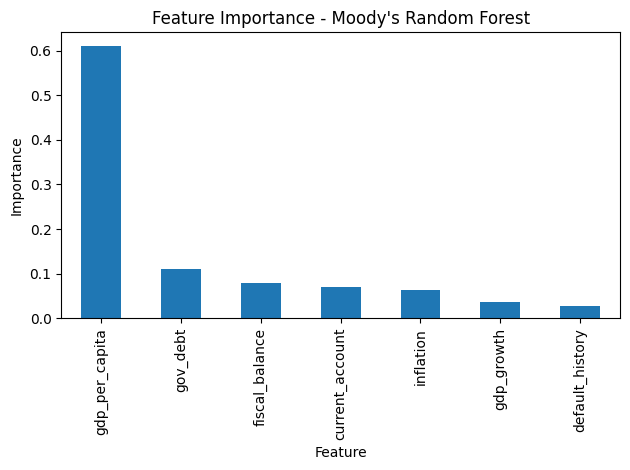

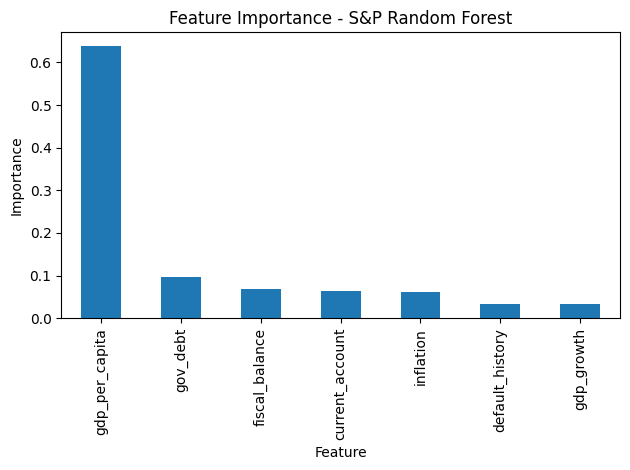

In [ ]:
# =====================================================================
# Feature Importance Histogram
# =====================================================================

import matplotlib.pyplot as plt

# Moody's Feature Importance
feat_imp_m = pd.Series(rf_m.feature_importances_, index=features).sort_values(ascending=False)
feat_imp_m.plot(kind='bar')
plt.title("Feature Importance - Moody's Random Forest")
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# S&P Feature Importance
feat_imp_s = pd.Series(rf_s.feature_importances_, index=features).sort_values(ascending=False)
feat_imp_s.plot(kind='bar')
plt.title("Feature Importance - S&P Random Forest")
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Feature Importance from Random Forest Models

This cell plots the feature importance scores from the random forest models for both Moody’s and S&P. Feature importance shows which macroeconomic variables the model relies on most when making predictions.

By comparing the importance across variables, we can see which factors are most influential in determining credit ratings and whether the model is driven by a small set of dominant variables or a broader mix of inputs.

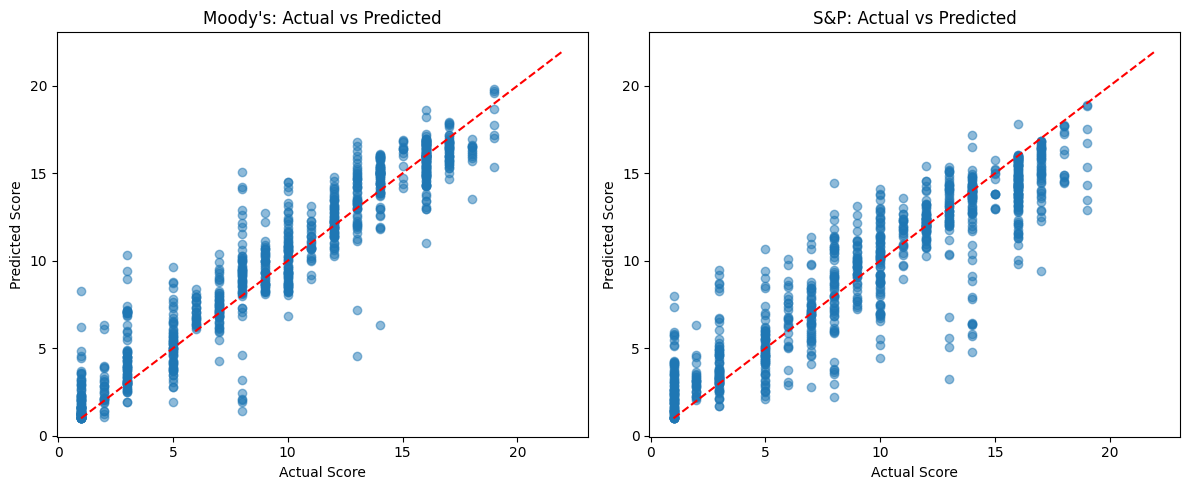

In [ ]:
# =====================================================================
# Actual vs Predicted Moody's and S&P
# =====================================================================

# Actual vs Predicted - Moody's
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, rf_m.predict(X_test), alpha=0.5)
axes[0].plot([1, 22], [1, 22], 'r--')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title("Moody's: Actual vs Predicted")

# Actual vs Predicted - S&P
axes[1].scatter(y_test, rf_s.predict(X_test), alpha=0.5)
axes[1].plot([1, 22], [1, 22], 'r--')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title("S&P: Actual vs Predicted")
plt.tight_layout()
plt.show()

### Actual vs Predicted Comparison

This cell plots predicted scores against actual scores for both Moody’s and S&P models. The diagonal line represents perfect predictions, so points closer to the line indicate better model accuracy.

This plot provides a visual check of model performance by showing how closely predictions match observed values and whether errors are evenly distributed or concentrated in certain ranges.

/tmp/ipykernel_221/2131239558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sorted_df, x='moodys_rating', palette='viridis')


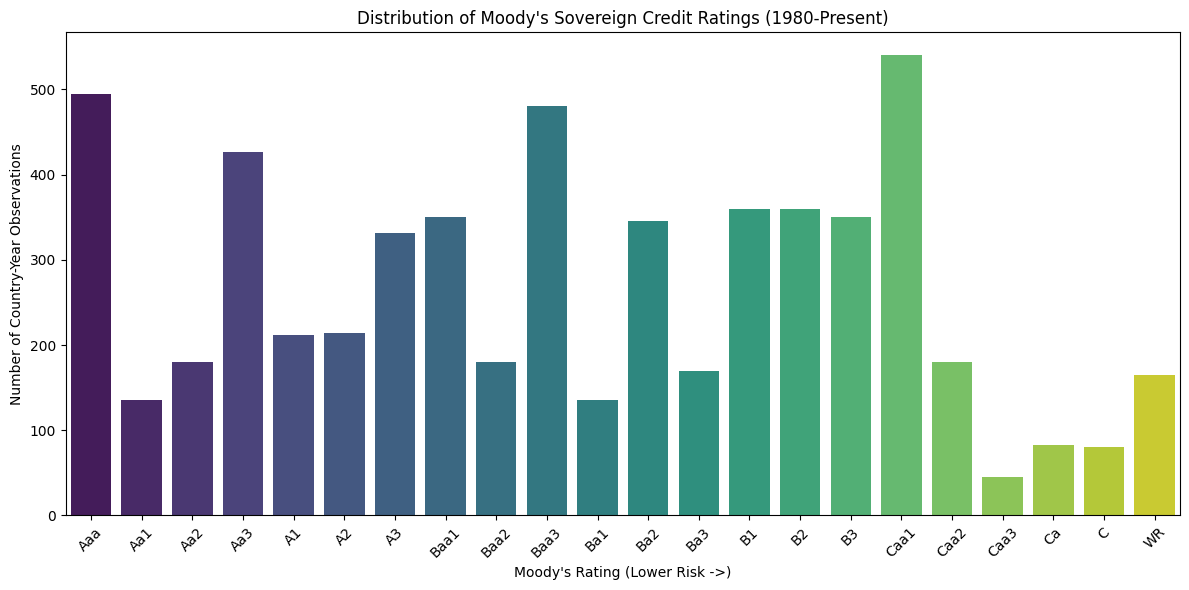

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#The EDA Chart: Distribution of Credit Ratings
plt.figure(figsize=(12, 6))
# We sort by score so the x-axis goes from Worst to Best rating
sorted_df = final_project_df.sort_values('moodys_score')

sns.countplot(data=sorted_df, x='moodys_rating', palette='viridis')
plt.title("Distribution of Moody's Sovereign Credit Ratings (1980-Present)")
plt.xlabel("Moody's Rating (Lower Risk ->)")
plt.ylabel("Number of Country-Year Observations")
plt.xticks(rotation=45)

# Save this for Overleaf
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=300)
plt.show()

### Distribution of Moody’s Credit Ratings

This cell plots the distribution of Moody’s ratings across all country year observations. The ratings are ordered from lower to higher credit quality to show how observations are spread across risk levels.

This helps give context for the modeling results by showing whether the data is balanced or concentrated in certain rating categories, which can affect how well the model learns different parts of the rating scale.

/tmp/ipykernel_221/1537947125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sorted_df, x='moodys_rating', y='gdp_per_capita', palette='coolwarm')


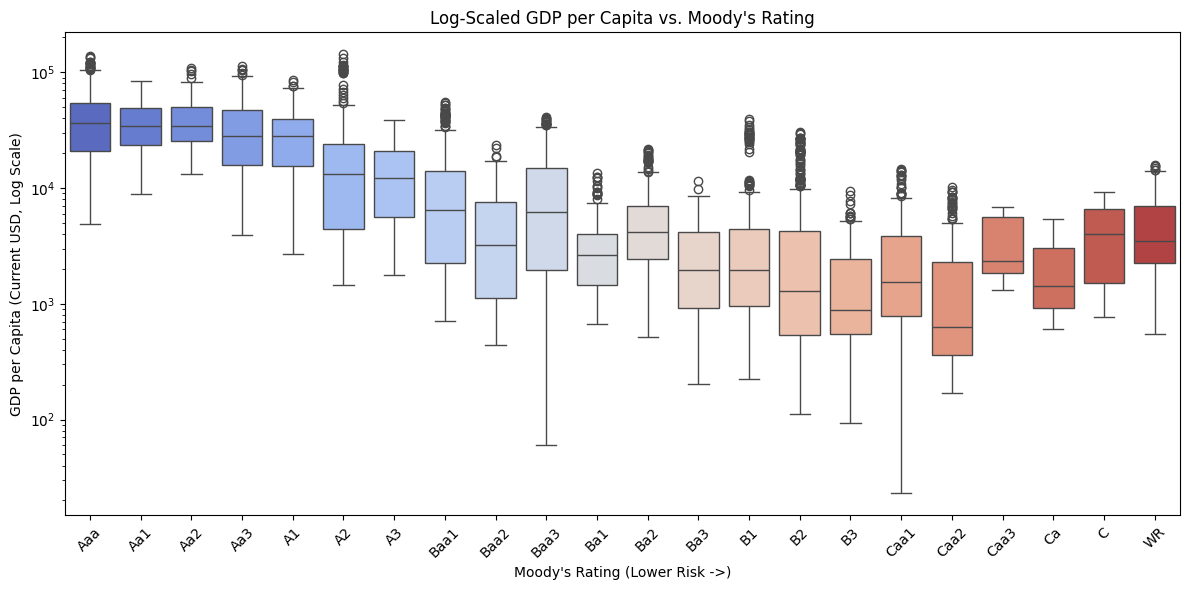

In [ ]:
#The Feature Analysis Chart: Wealth vs. Creditworthiness
plt.figure(figsize=(12, 6))
# Using a log scale because GDP ranges from $22 to $288,000
sns.boxplot(data=sorted_df, x='moodys_rating', y='gdp_per_capita', palette='coolwarm')
plt.yscale('log')

plt.title("Log-Scaled GDP per Capita vs. Moody's Rating")
plt.xlabel("Moody's Rating (Lower Risk ->)")
plt.ylabel("GDP per Capita (Current USD, Log Scale)")
plt.xticks(rotation=45)

# Save this for Overleaf
plt.tight_layout()
plt.savefig('gdp_vs_rating.png', dpi=300)
plt.show()

### GDP per Capita and Credit Ratings

This cell plots GDP per capita against Moody’s ratings using a boxplot. The y-axis is shown on a log scale because income levels vary widely across countries.

This visualization helps show how economic development relates to creditworthiness. It provides an intuitive check on whether higher income countries tend to have better ratings, which supports the variables used in the models.

In [ ]:
# Generate predictions
rf_m_data['predicted_score'] = rf_m.predict(X_m)

# Calculate the absolute error (how far off the model was)
rf_m_data['error'] = abs(rf_m_data['moodys_score'] - rf_m_data['predicted_score'])

# Bring back the country names from the original dataframe using the index!
rf_m_data['country_name'] = final_project_df['country_name']

# Look at the top 10 countries the model got WRONG
missed_countries = rf_m_data.sort_values('error', ascending=False).head(10)
display(missed_countries[['country_name', 'moodys_score', 'predicted_score', 'error']])

,country_name,moodys_score,predicted_score,error
983,Belarus,22.0,10.61,11.39
898,"Bahamas, The",14.0,3.48,10.52
985,Belarus,22.0,11.74,10.26
981,Belarus,22.0,12.18,9.82
884,"Bahamas, The",14.0,4.56,9.44
6442,Trinidad and Tobago,12.0,2.59,9.41
980,Belarus,22.0,12.70,9.30
834,Bahrain,15.0,5.84,9.16
833,Bahrain,15.0,6.33,8.67
23,Aruba,10.0,1.42,8.58


### Largest Prediction Errors

This cell identifies the observations with the largest prediction errors from the Moody’s random forest model. It compares actual and predicted scores and ranks the results by absolute error.

Looking at the worst predictions helps highlight specific country-year cases where the model performs poorly. This is useful for understanding the limits of the model and identifying patterns that are not well captured by the macroeconomic variables.

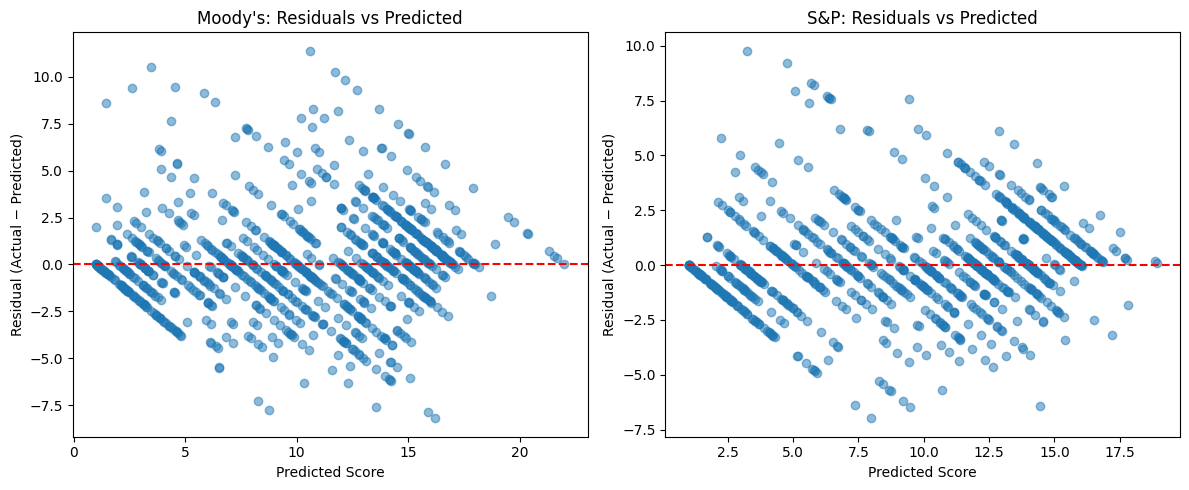

In [ ]:
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    rf_m_data[features], rf_m_data['moodys_score'], test_size=0.2, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    rf_s_data[features], rf_s_data['sp_score'], test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name, X_t, y_t in [
    (axes[0], rf_m, "Moody's", X_test_m, y_test_m),
    (axes[1], rf_s, "S&P",     X_test_s, y_test_s)]:
    pred = model.predict(X_t)
    resid = y_t - pred
    ax.scatter(pred, resid, alpha=0.5)
    ax.axhline(0, color='r', linestyle='--')
    ax.set_xlabel('Predicted Score')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f"{name}: Residuals vs Predicted")
plt.tight_layout(); plt.show()

### Residual Plots for Random Forest Models

This cell plots residuals for the Moody’s and S&P random forest models. Residuals are calculated as the difference between actual and predicted scores.

By plotting residuals against predicted values, we can check whether errors are spread randomly or follow a pattern. Random scatter suggests the model is capturing the relationship well, while visible patterns or large clusters of errors indicate areas where the model is missing important information.

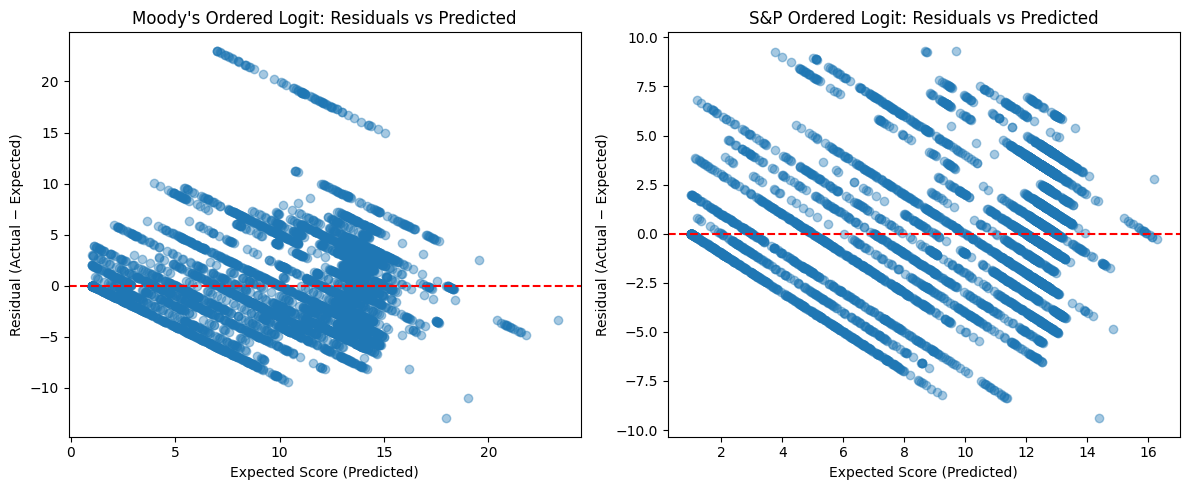

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === Moody's expected scores ===
# res_m.predict() returns probabilities for each rating category
probs_m = res_m.predict(logit_m[features])  # shape: (n, n_categories)

# Map each category to its numeric score
# logit_m is sorted by moodys_score ascending, so categories align with sorted unique scores
score_map_m = logit_m.drop_duplicates('moodys_rating').sort_values('moodys_score')['moodys_score'].values
expected_score_m = probs_m.values @ score_map_m
resid_m = logit_m['moodys_score'].values - expected_score_m

# === S&P expected scores ===
probs_s = res_s.predict(logit_s[features])
score_map_s = logit_s.drop_duplicates('sp_rating').sort_values('sp_score')['sp_score'].values
expected_score_s = probs_s.values @ score_map_s
resid_s = logit_s['sp_score'].values - expected_score_s

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(expected_score_m, resid_m, alpha=0.4)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Expected Score (Predicted)')
axes[0].set_ylabel('Residual (Actual − Expected)')
axes[0].set_title("Moody's Ordered Logit: Residuals vs Predicted")

axes[1].scatter(expected_score_s, resid_s, alpha=0.4)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Expected Score (Predicted)')
axes[1].set_ylabel('Residual (Actual − Expected)')
axes[1].set_title("S&P Ordered Logit: Residuals vs Predicted")

plt.tight_layout()
plt.savefig('logit_residuals.png', dpi=300)
plt.show()

### Ordered Logit Residual Plots

This cell creates residual plots for the Moody’s and S&P ordered logit models. Since ordered logit predicts probabilities for each rating category, we first convert those probabilities into an expected numeric score and compare that expected score with the actual rating score.

The plots help check whether the ordered logit models make errors evenly across the rating scale or whether certain predicted score ranges have larger mistakes. This gives us a visual diagnostic for the baseline econometric model.

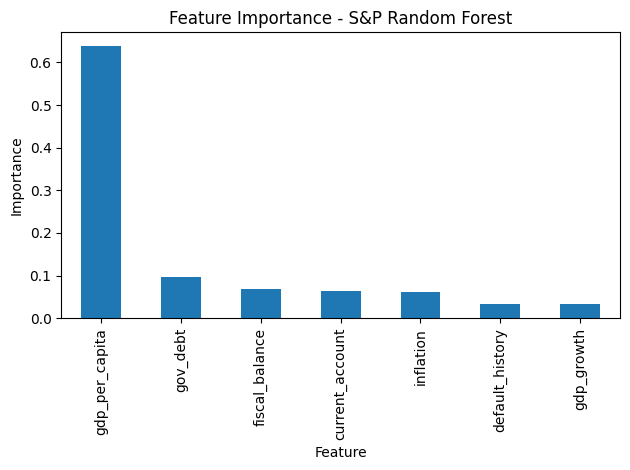

In [ ]:
# S&P Feature Importance
feat_imp_s = pd.Series(rf_s.feature_importances_, index=features).sort_values(ascending=False)
feat_imp_s.plot(kind='bar')
plt.title("Feature Importance - S&P Random Forest")
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()

# ADD THESE TWO LINES TO SAVE IT:
plt.savefig('sp_feature_importance.png', dpi=300)

plt.show()

### S&P Random Forest Feature Importance

This cell visualizes the relative importance of each feature in the S&P random forest model. Feature importance measures how much each variable contributes to reducing prediction error across the trees.

The goal is to understand which macroeconomic factors the model relies on most when predicting credit ratings, and to compare these patterns with the econometric results.

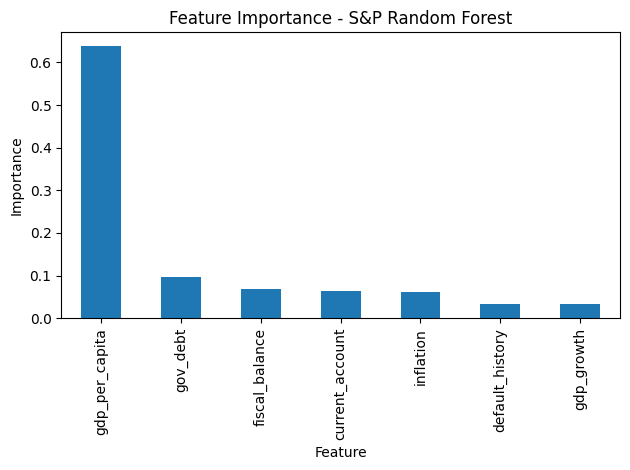

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# S&P Feature Importance
feat_imp_s = pd.Series(rf_s.feature_importances_, index=features).sort_values(ascending=False)
feat_imp_s.plot(kind='bar')
plt.title("Feature Importance - S&P Random Forest")
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### S&P Feature Importance Visualization

This cell plots the feature importance from the S&P random forest model. Each bar shows how much a variable contributes to the model’s predictions.

This helps us see which macroeconomic indicators matter most in the machine learning model and whether they align with the patterns found in the ordered logit results.

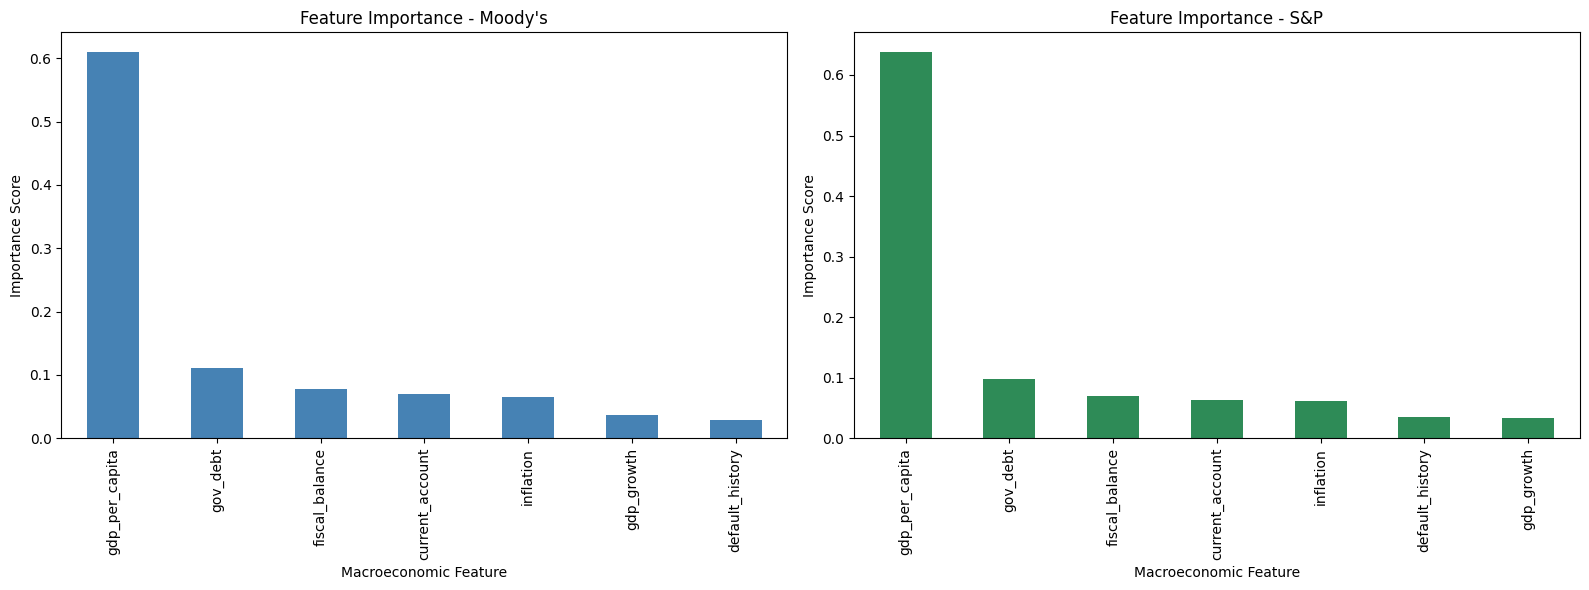

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Moody's on the left (axes[0])
feat_imp_m.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Feature Importance - Moody's")
axes[0].set_ylabel('Importance Score')
axes[0].set_xlabel('Macroeconomic Feature')

# Plot S&P on the right (axes[1])
feat_imp_s.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("Feature Importance - S&P")
axes[1].set_ylabel('Importance Score')
axes[1].set_xlabel('Macroeconomic Feature')

# Adjust layout so labels don't overlap
plt.tight_layout()

# Save the combined version for your records if you like
plt.savefig('combined_feature_importance.png', dpi=300)

plt.show()

### Combined Feature Importance Comparison

This cell places the feature importance results for Moody’s and S&P side by side. Each chart shows how much each macroeconomic variable contributes to the predictions in the random forest model.

Displaying both models together makes it easier to compare whether the two agencies rely on similar underlying signals, and highlights any differences in how the models weight economic indicators.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6fb9f9ac-95d2-47f1-8fa3-4c6e2f405d7e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>